In [233]:
%reload_ext autoreload
%autoreload 2

In [234]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM, VP
from probjax.nn.nets.simple import ResNet

from probjax.utils.special import digammainv

In [235]:
jax.devices()

[CudaDevice(id=0)]

In [929]:
std = 0.005

In [930]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey1, subkey2, subkey_noise = jax.random.split(key, 4)
    theta = jax.random.normal(subkey1, ())
    x = theta**2 + jax.random.normal(subkey2, ())*std
    return theta[None],x[None]


def unnormalized_posterior(theta, x):
    prior = jax.scipy.stats.norm.logpdf(theta, 0., 1.)
    likelihood = jax.scipy.stats.norm.logpdf(x, theta**2,std)
    return jnp.sum(prior + likelihood, axis=-1)

def unnormalized_posterior_grad(theta, x):
    return jax.grad(unnormalized_posterior)(theta, x)


[1.372]


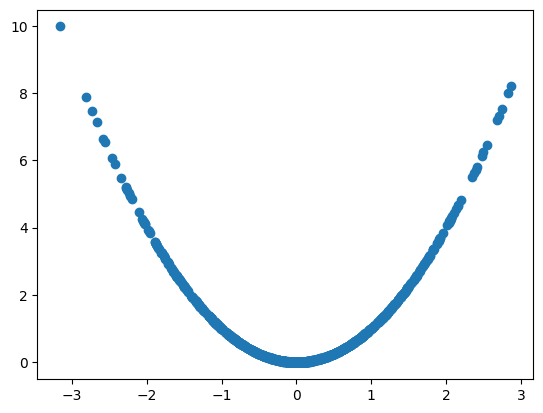

In [931]:
thetas, xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
plt.scatter(thetas, xs)

In [993]:
d = 1
class BaseModel(nnx.Module):
    def __init__(self, d,d_context, rngs, time_embed_dim=32) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,time_embed_dim, rngs=rngs)
        self.resnet = ResNet(time_embed_dim,d,rngs,context_dim=2*time_embed_dim, hidden_dim=500, num_hidden_layers=4)

    def __call__(self, t,x, context, *args, **kwargs):
        time_embed = self.time_embedding(t)
        # Pad context by repeating until it matches the time embedding
        context_embed = jnp.repeat(context, self.time_embedding.output_dim, axis=-1)
        context_emb = jnp.concatenate([context_embed, time_embed], axis=-1)
        x = jnp.repeat(x, self.time_embedding.output_dim, axis=-1)
        # Run through resnet
        output = self.resnet(x, context_emb)
        return output

net = BaseModel(1, 1,nnx.Rngs(0))
model = EDM(net, std0=1., loss_type="v")
params = nnx.state(model, nnx.Param)

In [994]:
nnx.display(model)

In [995]:

import optax

opt = optax.chain(optax.adam(1e-4))
opt_state = opt.init(params)


def loss_fn(params, rng, x, context):
    nnx.update(model, params)
    rng1, rng2 = jax.random.split(rng)

    t = model.noise_schedule(rng1, (x.shape[0],))
    target_score = jax.vmap(unnormalized_posterior_grad)(x, context)

    theta_noisy = x + t * jax.random.normal(rng2, x.shape)
    approx_score = model.score(t, theta_noisy, context)

    target_score_norm = jnp.sum(target_score**2, axis=-1)**0.5
    cutoff = t[...,0] < 0.05
    N_el = cutoff.sum()
    target_score_norm = jnp.where(cutoff, target_score_norm, 0.).sum()/N_el
    #weight = jnp.where(cutoff,(t[...,0]/(target_score_norm + t[...,0])), 0.)
    #jax.debug.print("{cutoff}", cutoff=cutoff.sum())
    weight = 1/target_score_norm * t[...,0]**2 * jnp.where(cutoff, 1., 0.)
    loss2 = jnp.sum( weight* jnp.sum((approx_score - target_score)**2, axis=-1)) * 1/cutoff.sum()
    loss = model.loss(rng, x, context)
    print(loss, loss2)
    return loss + loss2

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params,rng, x[0], context=x[1])
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [996]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 5_000))
loss_fn(params, jax.random.key(0), xs[0], xs[1])

1.3014829 0.7048429


Array(2.006, dtype=float32)

In [997]:
opt_state = opt.init(params)

In [998]:
key = jax.random.key(0)

In [ ]:
losses = []
for i in range(1200):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 2_000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/10)

Traced<ShapedArray(float32[])>with<JVPTrace> with
  primal = Traced<ShapedArray(float32[])>with<DynamicJaxprTrace>
  tangent = Traced<ShapedArray(float32[])>with<JaxprTrace> with
    pval = (ShapedArray(float32[]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7f27573656f0>, in_tracers=(Traced<ShapedArray(float32[2000]):JaxprTrace>,), out_tracer_refs=[<weakref at 0x7f275ea47650; to 'JaxprTracer' at 0x7f275ea470c0>], out_avals=[ShapedArray(float32[])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[2000]. let
    b:f32[] = reduce_sum[axes=(0,)] a
    c:f32[] = div b 2000.0
  in (c,) }, 'in_shardings': (UnspecifiedValue,), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None,), 'out_layouts': (None,), 'resource_env': None, 'donated_invars': (False,), 'name': '_mean', 'keep_unused': False, 'inline': True, 'compiler_options_kvs': ()}, effects=set(), source_info=<jax._src.source_info_util.SourceInfo object at 0x7f2756d5e560>, ctx=JaxprEqnContext(compute_type=None, thr

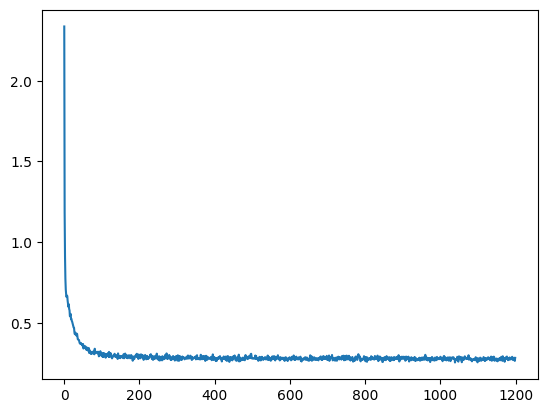

In [ ]:
plt.plot(losses)

In [981]:
nnx.update(model, params)

In [982]:
thetas, xs = jax.vmap(generate_data)(jax.random.split(key, 1000))

approx_score = model.score(jnp.ones((thetas.shape[0],1))*0.05, thetas, xs)
target_score = jax.vmap(unnormalized_posterior_grad)(thetas, xs)

In [ ]:
jnp.mean((approx_score - target_score)**2)

Array(147125.48, dtype=float32)

In [984]:
# Cosine similarity between scores for batch of 1000
jnp.mean(jnp.sum(approx_score * target_score, axis=-1) / (jnp.linalg.norm(approx_score, axis=-1) * jnp.linalg.norm(target_score, axis=-1)))


Array(0.458, dtype=float32)

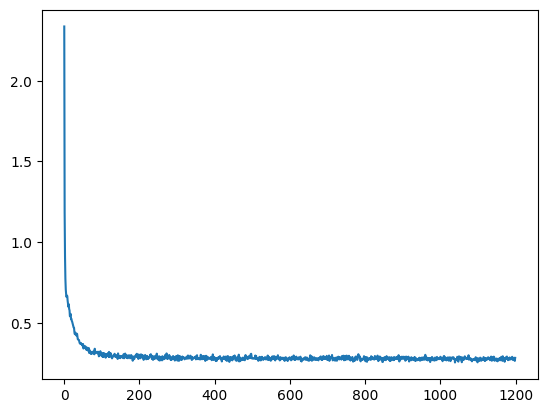

In [985]:
plt.plot(losses)


In [986]:
from probjax.utils.odeint import odeint


def sample(rng, context):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(1000)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context)
        return (f -0.5*g**2*score).reshape(x.shape)

    ys =  odeint(drift, eps,ts, method="heun")
    # Last step with euler
    ys_last_euler = ys[-1] - ts[-1] * drift(ts[-1], ys[-1])
    return jnp.concatenate([ys, ys_last_euler[None]], axis=0)


In [987]:
keys = jax.random.split(key,  (10_000,))

In [988]:
x_o = jnp.array([.5])
xs = jax.vmap(lambda k: sample(k, context=x_o))(keys)

(-10.0, 10.0)

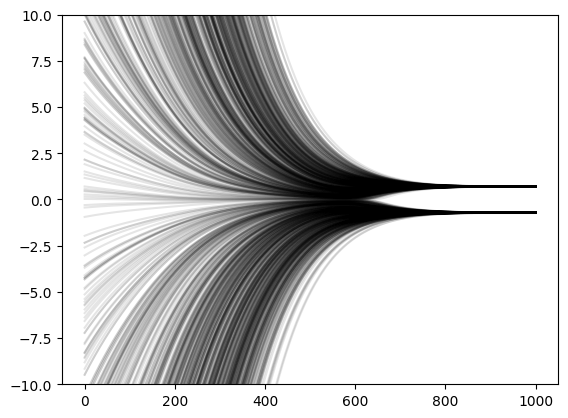

In [989]:
_ = plt.plot(xs[::10,:,0].T, alpha=0.1, color="black")
plt.ylim(-10,10)

In [968]:
# True posterior
thetas = jnp.linspace(-.8,0.8,20_000)
log_posterior = jax.vmap(lambda theta: jnp.mean(unnormalized_posterior(theta, x_o)))(thetas)
posterior_pdf = jnp.exp(log_posterior)
Z = jnp.trapezoid(posterior_pdf, thetas)
posterior_pdf /= Z

(-0.8, -0.6)

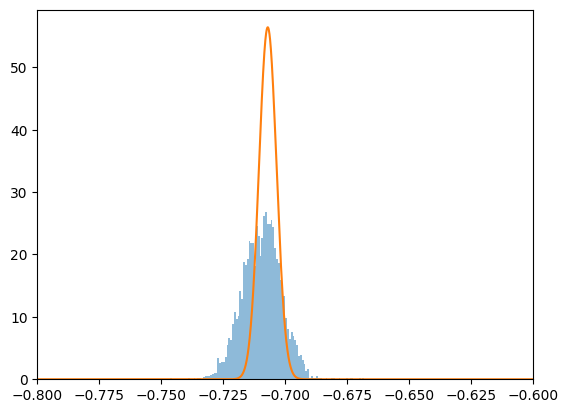

In [969]:
_ = plt.hist(xs[:,-1].flatten(), bins=2000, density=True, alpha=0.5)
plt.plot(thetas, posterior_pdf)

plt.xlim(-0.8, -0.6)

In [903]:
from probjax.utils.sdeint import sdeint


def sample(rng, context):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(500)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x, context=context)

        drift_backward = f - g**2 * score
        return drift_backward

    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g

    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")


In [417]:
keys = jax.random.split(key, (10_000,))

In [418]:
xs = jax.vmap(lambda k: sample(k, context=x_o))(keys)

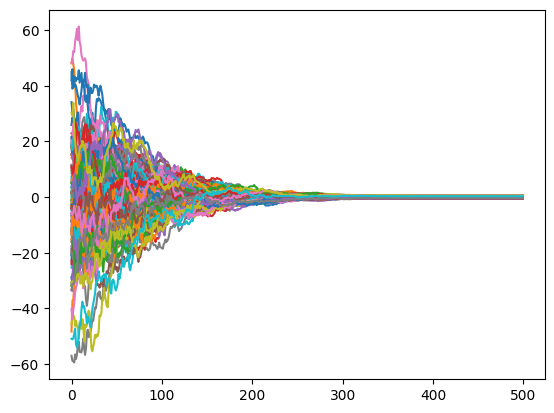

In [419]:
_ = plt.plot(xs[::100,:,0].T)

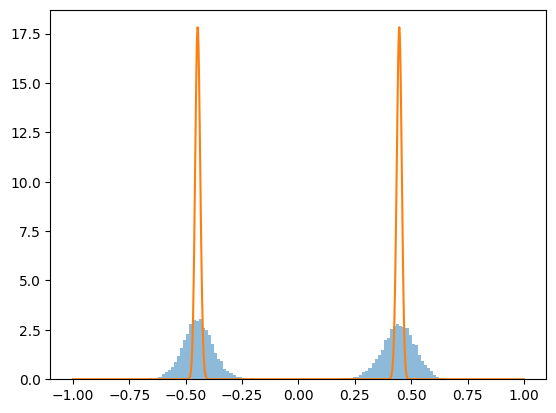

In [420]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, alpha=0.5)
plt.plot(thetas, posterior_pdf)